# Exercício:

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
aa_list = list("ACDEFGHIKLMNPQRSTVWY")

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [40]:
df = pd.read_csv('../storage/aula_013.csv')
df = df.set_index("gene_name")
def medidas_tendencia_central(serie:pd.Series):
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()[0]  
    return media, mediana, moda
df


,sigil,ref_code,sequence,A,C,D,E,F,G,H,...,M,N,P,Q,R,S,T,V,W,Y
gene_name,,,,,,,,,,,,,,,,,,,,,
APOE,RecName:,sp|P02649.1|APOE_HUMAN,MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWEL...,39,2,11,40,4,18,2,...,8,1,8,32,34,14,12,24,8,4
BRCA1,BRCA1,AAC37594.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,84,44,85,198,49,87,49,...,30,121,96,97,76,224,111,101,10,31
EGFR,EGFR,AAI18666.1,MAAEDVIICAQQCSGRCRGKSPSDCCHNQCAAGCTGPRESDCLVCR...,25,42,22,27,11,45,15,...,7,26,28,13,22,26,28,26,4,9
TP53,"TP53,",AYF55702.1,WVDSTPPPGTRVRAVAIYKQSQHMTEVVRRCPHHERCSDSD,2,2,3,2,0,1,3,...,1,0,4,2,5,4,3,5,1,1
VEGFA,VEGFA,CAP2943360.1,MFKAVRGQRSPHHSSALAGNVGHIISHRHENKGRLQAARLFTLFVQ...,11,17,9,18,10,10,12,...,4,7,12,11,20,14,7,14,1,4


In [10]:
serina_counts = df['S']
media, mediana, moda = medidas_tendencia_central(serina_counts)

print("Serina em todos os genes:")
print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

terceiro_gene = df.iloc[2] 
serina_terceiro = terceiro_gene['S']

print("\nSerina no terceiro gene:")
print(f"Valor absoluto: {serina_terceiro}")

Serina em todos os genes:
Média: 56.4
Mediana: 14.0
Moda: 14

Serina no terceiro gene:
Valor absoluto: 26


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [14]:
def amplitude(serie:pd.Series):
  return serie.max() - serie.min()

isoleucina_counts = df['I']
amp_isoleucina = amplitude(isoleucina_counts)

print(f"Amplitude da Isoleucina: {amp_isoleucina}")

ultimo_gene = df.iloc[-1]  
last_leu = ultimo_gene['I']
amp_ultimo = amplitude(last_leu)

print(f"Amplitude do último gene: {amp_ultimo}")

Amplitude da Isoleucina: 76
Amplitude do último gene: 0


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [15]:
def quartis(serie:pd.Series):
    q1 = serie.quantile(0.25)
    q2 = serie.quantile(0.50) 
    q3 = serie.quantile(0.75)
    return q1, q2, q3


In [ ]:
metionina_counts = df['M']
q1, q2, q3 = quartis(metionina_counts)

print("Quartis da Metionina em todos os genes:")
print(f"Q1: {q1}")
print(f"Q2 (Mediana): {q2}")
print(f"Q3: {q3}")

primeiro_gene = df.iloc[0][aa_list]
q1_gene, q2_gene, q3_gene = quartis(primeiro_gene)

print("\nQuartis do primeiro gene (todos os aminoácidos):")
print(f"Q1: {q1_gene}")
print(f"Q2 (Mediana): {q2_gene}")
print(f"Q3: {q3_gene}") 

Quartis da Metionina em todos os genes:
Q1: 4.0
Q2 (Mediana): 7.0
Q3: 8.0

Quartis do primeiro gene (todos os aminoácidos):
Q1: 4.0
Q2 (Mediana): 11.5
Q3: 26.0


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [19]:
def intervalo_interquartil(serie:pd.Series):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    return q3 - q1


In [ ]:
glutamico_counts = df['E']
iqr_glutamico = intervalo_interquartil(glutamico_counts)

print(f"Intervalo interquartil do Ácido Glutâmico: {iqr_glutamico}")

penultimo_gene = df.iloc[-2][aa_list]
iqr_penultimo = intervalo_interquartil(penultimo_gene)

print(f"Intervalo interquartil do penúltimo gene: {iqr_penultimo}")


Intervalo interquartil do Ácido Glutâmico: 22.0
Intervalo interquartil do penúltimo gene: 2.0


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [ ]:
def variancia_amostral(serie:pd.Series):
    return serie.var(ddof=1)  


In [25]:
prolina_counts = df['P']
var_prolina = variancia_amostral(prolina_counts)

print(f"Variância amostral da Prolina: {var_prolina}")


Variância amostral da Prolina: 1460.8000000000006


In [ ]:
terceiro_gene = df.iloc[2][aa_list]
var_terceiro = variancia_amostral(terceiro_gene)

print(f"Variância amostral do terceiro gene: {var_terceiro}")


Variância amostral do terceiro gene: 116.69473684210526


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [ ]:
def desvio_padrao(serie:pd.Series):
    return serie.std(ddof=1)  


In [29]:
triptofano_counts = df['W']
dp_triptofano = desvio_padrao(triptofano_counts)

print(f"Desvio padrão do Triptofano: {dp_triptofano}")


Desvio padrão do Triptofano: 4.08656334834051


In [ ]:
ultimo_gene = df.iloc[-1][aa_list]
dp_ultimo = desvio_padrao(ultimo_gene)

print(f"Desvio padrão do ultimo gene: {dp_ultimo}")

Desvio padrão do gene de índice -1: 4.978638579497728


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [31]:
def coeficiente_variacao(serie:pd.Series):
    media = serie.mean()
    desvio = serie.std(ddof=1) 
    return desvio / media if media != 0 else float('nan')


In [32]:
leucina_counts = df['L']
cv_leucina = coeficiente_variacao(leucina_counts)

print(f"Coeficiente de variação da Leucina: {cv_leucina}")


Coeficiente de variação da Leucina: 1.2648122801915238


In [ ]:
gene_index1 = df.iloc[1][aa_list]
cv_gene1 = coeficiente_variacao(gene_index1)

print(f"Coeficiente de variação do segundo gene: {cv_gene1}")


Coeficiente de variação do gene de índice 1: 0.5879415375815972


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [34]:
def medidas_resumo(serie:pd.Series):
    resumo = {
        "mínimo": serie.min(),
        "Q1": serie.quantile(0.25),
        "mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "máximo": serie.max(),
        "média": serie.mean(),
        "variância": serie.var(ddof=1),
        "desvio_padrão": serie.std(ddof=1),
        "amplitude": serie.max() - serie.min(),
        "coef_variação": serie.std(ddof=1) / serie.mean() if serie.mean() != 0 else float('nan')
    }
    return resumo


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [35]:
def gene_maior_cv(df):
    aminoacids = list("ACDEFGHIKLMNPQRSTVWY")
    cvs = {}
    for idx, row in df.iterrows():
        serie = row[aminoacids]
        media = serie.mean()
        desvio = serie.std(ddof=1)
        cv = desvio / media if media != 0 else float('nan')
        cvs[idx] = cv
    # retorna o gene com maior CV
    gene_max = max(cvs, key=cvs.get)
    return gene_max, cvs[gene_max]


In [42]:
gene_max, cv_max = gene_maior_cv(df)
print(f"O gene com maior coeficiente de variação é {gene_max}, com CV = {cv_max:.4f}")


O gene com maior coeficiente de variação é APOE, com CV = 0.8833


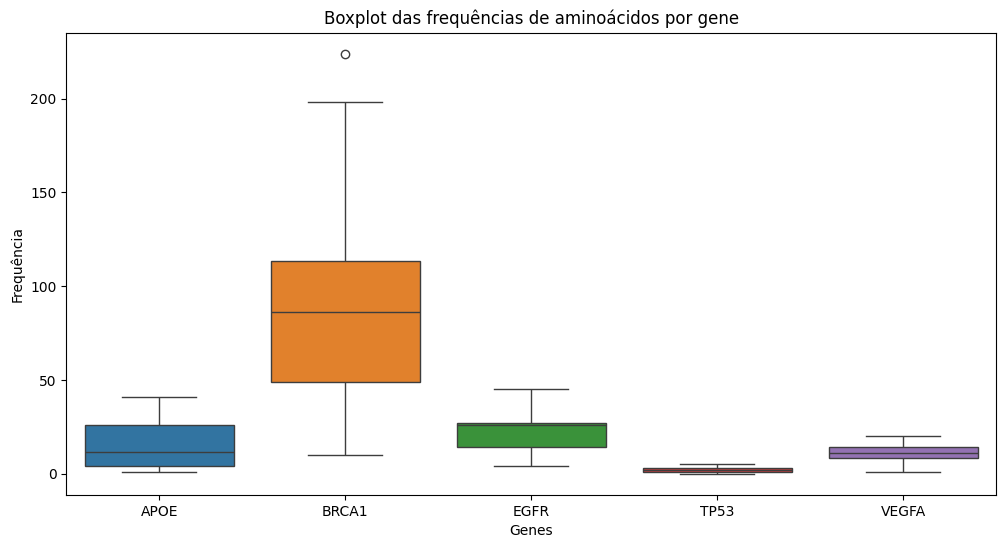

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

aminoacids = list("ACDEFGHIKLMNPQRSTVWY")

plt.figure(figsize=(12,6))
sns.boxplot(data=df[aminoacids].T)
plt.title("Boxplot das frequências de aminoácidos por gene")
plt.ylabel("Frequência")
plt.xlabel("Genes")
plt.xticks(range(len(df)), df.index)  
plt.show()


Olhando de forma grosseira pode parecer que a variancia de BRCA1 seria maior que a de APOE, mas , na verdade BRCA1 possui mais aminoácidos o que empurra a média para cima, o coeficiente de variação é calculado pela divisão do desvio padrão pela média, os valores de APOE são menores, portanto  comparar de forma absoluta não faz sentido.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [44]:
def aminoacido_maior_cv(df):
    aminoacids = list("ACDEFGHIKLMNPQRSTVWY")
    cvs = {}
    for aa in aminoacids:
        serie = df[aa]
        media = serie.mean()
        desvio = serie.std(ddof=1)
        cv = desvio / media if media != 0 else float('nan')
        cvs[aa] = cv
    aa_max = max(cvs, key=cvs.get)
    return aa_max, cvs[aa_max], cvs


In [45]:
aa_max, cv_max, cvs = aminoacido_maior_cv(df)
print(f"O aminoácido com maior coeficiente de variação é {aa_max}, com CV = {cv_max:.4f}")


O aminoácido com maior coeficiente de variação é S, com CV = 1.6669


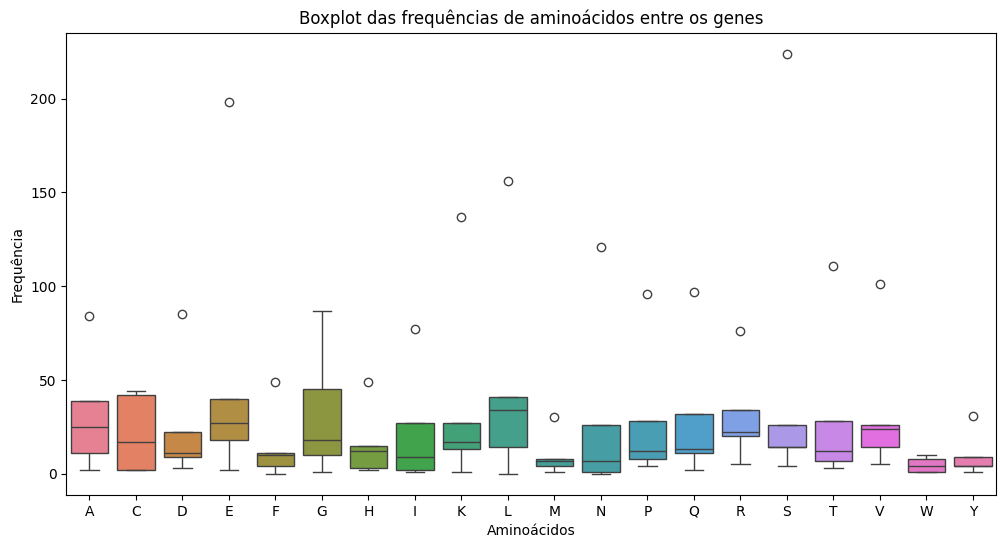

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

aminoacids = list("ACDEFGHIKLMNPQRSTVWY")

plt.figure(figsize=(12,6))
sns.boxplot(data=df[aminoacids])
plt.title("Boxplot das frequências de aminoácidos entre os genes")
plt.ylabel("Frequência")
plt.xlabel("Aminoácidos")
plt.show()
